In [1]:
!pip install pandas matplotlib folium

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
from IPython.display import display
from pathlib import Path


In [3]:
rutas_posibles = [
    Path("area_protegida.csv"),
    Path("/mnt/data/area_protegida.csv")
]

archivo_csv = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if archivo_csv is None:
    raise FileNotFoundError(
        "No se cargo ningun archivo.csv"
    )

df = pd.read_csv(archivo_csv)

print("Archivo cargado:", archivo_csv)
print("Cantidad de filas:", len(df))
print("Cantidad de columnas:", len(df.columns))

Archivo cargado: area_protegida.csv
Cantidad de filas: 395
Cantidad de columnas: 14


In [4]:
df.head()

,lat,lng,gid,entidad,objeto,fna,gna,nam,tap,jap,caa,fdc,sag,area
0,-53.546655,-68.041297,362,falso,Área protegida,Sitio RAMSAR y Reserva Hemisférica Costa Atlán...,Sitio RAMSAR y Reserva Hemisférica,Costa Atlántica de Tierra del Fuego,2,2,17,SIB/IGN/Ley Provincial Nº 415/1998,IGN,762166
1,-31.404445,-64.357709,157,falso,Área protegida,Reserva Natural de la Defensa La Calera,Reserva Natural de la Defensa,La Calera,2,2,17,SIB/IGN/Protocolo adicional Nº 05/2009,IGN,136225
2,-32.245004,-60.734423,169,falso,Área protegida,Sitio Ramsar Delta del Parana,Sitio Ramsar,Delta del Parana,2,2,17,NaN,MAyDS,2430979
3,-26.031780,-54.418743,47,falso,Área protegida,Parque Natural Municipal Lote C Huerto Municipal,Parque Natural Municipal,Lote C Huerto Municipal,1,4,17,SIB/IGN/Disposición Nº 45/95,IGN,955
4,-26.402258,-65.680992,206,falso,Área protegida,Parque Provincial Cumbres Calchaquíes,Parque Provincial,Cumbres Calchaquíes,1,3,17,NaN,IGN,706222


In [5]:
print("filas, columnas:", df.shape)

print("\nColumnas:")
print(df.columns.tolist())


filas, columnas: (395, 14)

Columnas:
['lat', 'lng', 'gid', 'entidad', 'objeto', 'fna', 'gna', 'nam', 'tap', 'jap', 'caa', 'fdc', 'sag', 'area']


In [6]:
print("Datos:")
display(df.dtypes.to_frame("tipo"))
print("\nValores nulos por columna:")
display(df.isna().sum().to_frame("nulos"))


Datos:


,tipo
lat,float64
lng,float64
gid,int64
entidad,str
objeto,str
fna,str
gna,str
nam,str
tap,int64
jap,int64



Valores nulos por columna:


,nulos
lat,0
lng,0
gid,0
entidad,0
objeto,0
fna,0
gna,0
nam,0
tap,0
jap,0


In [7]:
df[["lat", "lng", "area"]].describe()


,lat,lng,area
count,395.000000,395.000000,3.950000e+02
mean,-34.081736,-63.443871,1.245242e+06
std,8.656543,5.700540,4.529211e+06
min,-56.690001,-73.402908,2.700000e+01
25%,-39.499168,-68.270641,1.018950e+04
50%,-31.877126,-64.634117,7.930000e+04
75%,-26.921686,-58.448079,6.227880e+05
max,-22.158684,-53.790940,5.823486e+07


In [8]:
tipo_area = {
    0: "no disponible",
    1: "Parque",
    2: "Reserva",
    3: "Monumento Nacional"
}

jurisdiccion = {
    -1: "no disponible (-1)",
    0: "no disponible (0)",
    2: "Nacional",
    3: "Provincial",
    4: "Municipal",
    5: "Privado"
}

df["tipo_area"] = df["tap"].map(tipo_area)
df["jurisdiccion"] = df["jap"].map(jurisdiccion)

df[["nam", "tap", "tipo_area", "jap", "jurisdiccion", "area"]].head()


,nam,tap,tipo_area,jap,jurisdiccion,area
0,Costa Atlántica de Tierra del Fuego,2,Reserva,2,Nacional,762166
1,La Calera,2,Reserva,2,Nacional,136225
2,Delta del Parana,2,Reserva,2,Nacional,2430979
3,Lote C Huerto Municipal,1,Parque,4,Municipal,955
4,Cumbres Calchaquíes,1,Parque,3,Provincial,706222


In [9]:
Información general: ¿Cuántas áreas protegidas hay? ¿Cuántos tipos diferentes (tap) existen?

Object `existen` not found.


In [10]:
areas_protegidas = len(df)
tap = df["tap"].nunique()

print("areas protegidas:", areas_protegidas)
print("en total hay:", tap, "distintos.")
print("ubicacion de cada tap:", sorted(df["tap"].unique()))


areas protegidas: 395
en total hay: 4 distintos.
ubicacion de cada tap: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


Frecuencias: ¿Cuál es el tipo de área protegida más común? ¿Cuál es la jurisdicción más frecuente?


In [11]:
frecuencia_tap = df["tap"].value_counts().sort_index()
tabla_de_frecuencia = pd.DataFrame({
    "tap": frecuencia_tap.index,
    "tipo": [tipo_area.get(x, "Otro") for x in frecuencia_tap.index],
    "cantidad": frecuencia_tap.values
})

display(tabla_de_frecuencia)

tap_mas_comun = df["tap"].value_counts().idxmax()
print(
    "los tap mas comunes son:",
    tipo_area[tap_mas_comun],
    f"(tap = {tap_mas_comun})",
    "-", df["tap"].value_counts().max(), "registros"
)


,tap,tipo,cantidad
0,0,no disponible,4
1,1,Parque,95
2,2,Reserva,284
3,3,Monumento Nacional,12


los tap mas comunes son: Reserva (tap = 2) - 284 registros


In [12]:
frecuencia_jap = df["jap"].value_counts().sort_index()
tabla_de_frecuencia_jap = pd.DataFrame({
    "jap": frecuencia_jap.index,
    "jurisdicción": [jurisdiccion.get(x, "Otra") for x in frecuencia_jap.index],
    "cantidad": frecuencia_jap.values
})

display(tabla_de_frecuencia_jap)

jap_mas_comun = df["jap"].value_counts().idxmax()
print(
    "las jurisdicciones mas frecuentes son:",
    jurisdiccion[jap_mas_comun],
    f"(jap = {jap_mas_comun})",
    "-", df["jap"].value_counts().max(), "registros"
)


,jap,jurisdicción,cantidad
0,-1,no disponible (-1),2
1,0,no disponible (0),3
2,2,Nacional,103
3,3,Provincial,222
4,4,Municipal,32
5,5,Privado,33


las jurisdicciones mas frecuentes son: Provincial (jap = 3) - 222 registros


Filtros: Mostrar todas las áreas protegidas de jurisdicción Nacional . ¿Cuántas son? ¿y cuántas Provincial y Privada?.

In [13]:
nacionales = df[df["jap"] == 2].copy()

print("Cantidad de áreas de jurisdicción Nacional:", len(nacionales))

with pd.option_context("display.max_rows", None):
    display(
        nacionales[
            ["nam", "area", "lat", "lng"]
        ].reset_index(drop=True)
    )


Cantidad de áreas de jurisdicción Nacional: 103


,nam,area,lat,lng
0,Costa Atlántica de Tierra del Fuego,762166,-53.546655,-68.041297
1,La Calera,136225,-31.404445,-64.357709
2,Delta del Parana,2430979,-32.245004,-60.734423
3,Perito Moreno,953034,-47.925458,-72.317514
4,Monte León,562692,-50.337227,-69.017112
5,Chaco,149308,-26.847979,-59.655168
6,Bosques Petrificados de Jaramillo,149918,-47.705861,-68.057843
7,Baterías - Charles Darwin,10113,-38.974724,-61.669072
8,Namuncurá - Banco Burdwood II,25855332,-55.166386,-59.875000
9,Namuncurá - Banco Burdwood,30740644,-54.293070,-59.187435


In [14]:
nacionales = (df["jap"] == 2).sum()
provinciales = (df["jap"] == 3).sum()
privadas = (df["jap"] == 5).sum()

print("Nacionales:", nacionales)
print("Provinciales:", provinciales)
print("Privadas:", privadas)


Nacionales: 103
Provinciales: 222
Privadas: 33


Respuesta: segun el codigo hay 103 areas de jurisdiccion nacional, 222 provinciales y 33 privadas.


Cálculo: ¿Cuál es el área promedio de los Parques Nacionales (tap == 1 y jap == 2)? ¿Y de las Reservas Provinciales (tap == 2 y jap == 3)?

In [15]:
parques_nacionales = df[(df["tap"] == 1) & (df["jap"] == 2)]
reservas_provinciales = df[(df["tap"] == 2) & (df["jap"] == 3)]

promedio_parques_nacionales = parques_nacionales["area"].mean()
promedio_reservas_provinciales = reservas_provinciales["area"].mean()

print("estos son todos los parques nacionales que hay:", len(parques_nacionales))
print("estas son las areas en promedio de los parques nacionales:", round(promedio_parques_nacionales, 2))

print("\nlo mismo con las reservas provinciales:", len(reservas_provinciales))
print("este es el promedio de area las reservas provinciales:", round(promedio_reservas_provinciales, 2))


estos son todos los parques nacionales que hay: 41
estas son las areas en promedio de los parques nacionales: 913448.27

lo mismo con las reservas provinciales: 165
este es el promedio de area las reservas provinciales: 1331852.9


In [16]:
#Gráfico: Realizar un gráfico con la cantidad de áreas protegidas por tipo (tap). Realizar un gráfico con la proporción por jurisdicción (jap).

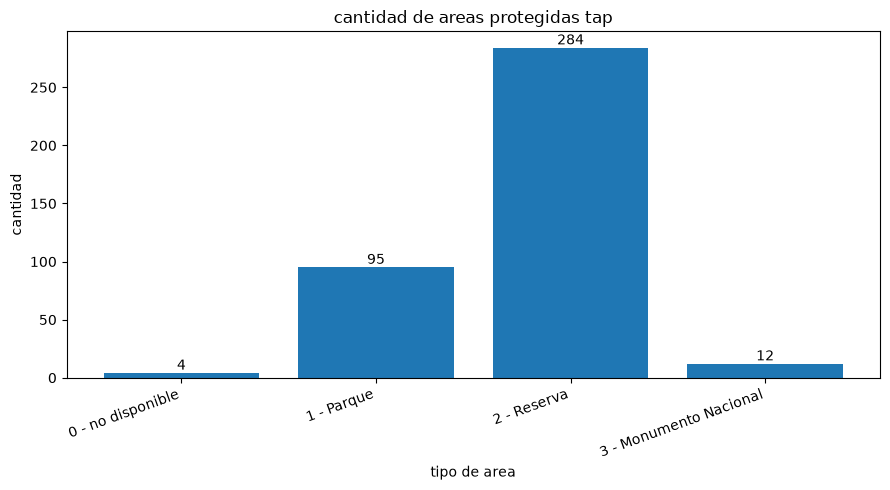

In [17]:
conteo = (
    df["tap"]
    .value_counts()
    .sort_index()
)

etiquetas = [
    f"{codigo} - {tipo_area.get(codigo, 'Otro')}"
    for codigo in conteo.index
]

plt.figure(figsize=(9, 5))
plt.bar(etiquetas, conteo.values)
plt.title("cantidad de areas protegidas tap")
plt.xlabel("tipo de area")
plt.ylabel("cantidad")
plt.xticks(rotation=20, ha="right")

for i, valor in enumerate(conteo.values):
    plt.text(i, valor + 3, str(valor), ha="center")

plt.tight_layout()
plt.show()


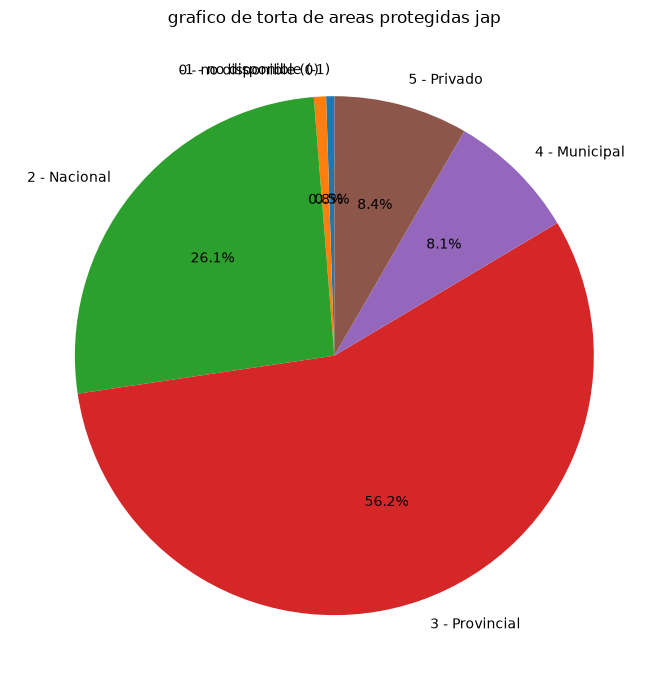

In [18]:
conteo = df["jap"].value_counts().sort_index()

etiquetas = [
    f"{codigo} - {jurisdiccion.get(codigo, 'Otra')}"
    for codigo in conteo.index
]

plt.figure(figsize=(9, 7))
plt.pie(
    conteo.values,
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("grafico de torta de areas protegidas jap")
plt.tight_layout()
plt.show()


Mapa: Generar un mapa con todas las áreas protegidas Parques, coloreando según la jurisdicción (jap).

In [19]:
parques = df[df["tap"] == 1].copy()

colores_jap = {
    -1: "gray",
    0: "lightgray",
    2: "blue",
    3: "green",
    4: "orange",
    5: "purple"
}

centro_lat = parques["lat"].mean()
centro_lng = parques["lng"].mean()

mapa_parques = folium.Map(
    location=[centro_lat, centro_lng],
    zoom_start=4,
    tiles="OpenStreetMap"
)

for _, fila in parques.iterrows():
    codigo_jap = int(fila["jap"])
    nombre_jap = jurisdiccion.get(codigo_jap, f"Código {codigo_jap}")

    folium.CircleMarker(
        location=[fila["lat"], fila["lng"]],
        radius=5,
        color=colores_jap.get(codigo_jap, "black"),
        fill=True,
        fill_opacity=0.8,
        tooltip=f"{fila['nam']} | {nombre_jap}",
        popup=(
            f"<b>{fila['nam']}</b><br>"
            f"tipo: Parque<br>"
            f"jurisdiccion: {nombre_jap}<br>"
            f"area: {fila['area']}"
        )
    ).add_to(mapa_parques)

leyenda_html = '''
<div style="
position: fixed;
bottom: 35px;
left: 35px;
z-index: 9999;
background-color: white;
border: 2px solid gray;
border-radius: 6px;
padding: 10px;
font-size: 13px;
">
<b>jurisdiccion</b><br>
<span style="color:blue;">●</span> Nacional<br>
<span style="color:green;">●</span> Provincial<br>
<span style="color:orange;">●</span> Municipal<br>
<span style="color:purple;">●</span> Privado<br>
<span style="color:gray;">●</span> No disponible
</div>
'''

mapa_parques.get_root().html.add_child(folium.Element(leyenda_html))

mapa_parques.save("mapa_parques_areas_protegidas.html")

print("cantidad de parques en el mapa:", len(parques))
print("mapa guardado como: mapa_parques_areas_protegidas.html")

mapa_parques


cantidad de parques en el mapa: 95
mapa guardado como: mapa_parques_areas_protegidas.html
